In [1]:
from scipy.io import loadmat
import h5py
import scienceplots
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import scipy
from scipy import stats
from scipy.optimize import minimize_scalar

In [ ]:
filename = f'./data/theta0_128_0407.mat'
initial_1 = scipy.io.loadmat(filename)['theta0']

In [ ]:
continuation_007 = loadmat('./data/continuation.mat')['continuation_007'][0]
continuation_005 = loadmat('./data/continuation.mat')['continuation_005'][0]
continuation = loadmat('./data/continuation.mat')['continuation'][0]
continuation_004 = loadmat('./data/continuation.mat')['continuation_004'][0]

In [ ]:
Omega_initial_007_1 = loadmat('./data/Omega_initial.mat')['Omega_initial_007_1'][0]
Omega_initial_005_1 = loadmat('./data/Omega_initial.mat')['Omega_initial_005_1'][0]
Omega_initial_005_2 = loadmat('./data/Omega_initial.mat')['Omega_initial_005_2'][0]
Omega_initial = loadmat('./data/Omega_initial.mat')['Omega_initial'][0]
Omega_initial_2 = loadmat('./data/Omega_initial.mat')['Omega_initial_2'][0]
Omega_initial_004_2 = loadmat('./data/Omega_initial.mat')['Omega_initial_004_2'][0]

In [ ]:
l_e003 = pd.read_excel("./data/l_e.xlsx",sheet_name="003", header=None) 
l_e004 = pd.read_excel("./data/l_e.xlsx",sheet_name="004", header=None) 
l_e005 = pd.read_excel("./data/l_e.xlsx",sheet_name="005", header=None) 
l_e007 = pd.read_excel("./data/l_e.xlsx",sheet_name="007", header=None)

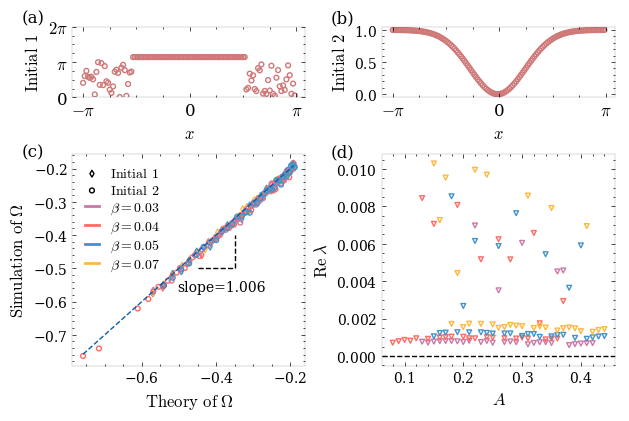

In [8]:
custom_colors = ['#FF6B64', '#CF7878', '#CB79A6', '#FEB83E',  '#4493C8']
point_size = 12
fs = 12
with plt.style.context(['science', 'no-latex']):
    fig = plt.figure(figsize=(7, 4.4))


    gs_main = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 3], hspace=0.4, wspace=0.33)

    N = 128
    x = np.linspace(-np.pi, np.pi, N, endpoint=False)

    ax = fig.add_subplot(gs_main[0,0])
    ax.text(-0.12, 1.25, '(a)', transform=ax.transAxes,ha='right', va='top', fontsize=12)
    ax.scatter(x, np.mod(initial_1, 2*np.pi), marker='o', facecolors='none', edgecolors=custom_colors[1], s = point_size)
    ax.set_ylim([0, 2*np.pi])
    ax.set_yticks([0, np.pi, 2*np.pi])
    ax.set_yticklabels(['0', r'$\pi$', r'$2\pi$'], fontsize = fs)
    ax.set_xticks([-np.pi,0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'], fontsize = fs)
    ax.set_xlabel(r'$x$', fontsize = fs)
    ax.set_ylabel(r'$\text{Initial 1}$', fontsize = fs)
    for spine in ax.spines.values():
        spine.set_linewidth(0.1)   
    

    ax = fig.add_subplot(gs_main[0,1])
    ax.text(-0.12, 1.25, '(b)', transform=ax.transAxes,ha='right', va='top', fontsize=12)
    initial_2 = 1-np.exp(-0.76*np.power((x - x[63]),2))
    ax.scatter(x, initial_2, marker='o', facecolors='none', edgecolors=custom_colors[1], s = point_size)
    ax.set_yticks([0, 0.5, 1])
    ax.set_xticks([-np.pi,0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'], fontsize = fs)
    ax.set_xlabel(r'$x$', fontsize = fs)
    ax.set_ylabel(r'$\text{Initial 2}$', fontsize = fs)
    for spine in ax.spines.values():
        spine.set_linewidth(0.1)   



    ax = fig.add_subplot(gs_main[1,0])
    ax.text(-0.12, 1.05, '(c)', transform=ax.transAxes,ha='right', va='top', fontsize=12)

    zz1 = []
    zz2 = []
    
    ax.scatter(
        continuation_007[0],
        Omega_initial_007_1[0],
        label=r'$\text{Initial 1}$',
        marker='d',
        facecolors='none',
        edgecolors='k',
        s=point_size
    )
    
    ax.scatter(
        continuation_007,
        Omega_initial_007_1,
        marker='d',
        facecolors='none',
        edgecolors=custom_colors[3],
        s=point_size
    )
    zz1.append(continuation_007)
    zz2.append(Omega_initial_007_1)
    
    ax.scatter(
        continuation_005,
        Omega_initial_005_1,
        marker='d',
        facecolors='none',
        edgecolors=custom_colors[4],
        s=point_size
    )
    zz1.append(continuation_005)
    zz2.append(Omega_initial_005_1)
    
    ax.scatter(
        continuation,
        Omega_initial,
        marker='d',
        facecolors='none',
        edgecolors=custom_colors[0],
        s=point_size
    )
    zz1.append(continuation)
    zz2.append(Omega_initial)
    
    ax.scatter(
        continuation_005[0],
        Omega_initial_005_2[0],
        label=r'$\text{Initial 2}$',
        marker='o',
        facecolors='none',
        edgecolors='k',
        s=point_size
    )
    
    ax.scatter(
        continuation_004,
        Omega_initial_004_2,
        marker='o',
        facecolors='none',
        edgecolors=custom_colors[0],
        s=point_size
    )
    zz1.append(continuation_004)
    zz2.append(Omega_initial_004_2)
    
    ax.scatter(
        continuation,
        Omega_initial_2,
        marker='o',
        facecolors='none',
        edgecolors=custom_colors[2],
        s=point_size
    )
    zz1.append(continuation)
    zz2.append(Omega_initial_2)
    
    ax.scatter(
        continuation_005,
        Omega_initial_005_2,
        marker='o',
        facecolors='none',
        edgecolors=custom_colors[4],
        s=point_size
    )
    zz1.append(continuation_005)
    zz2.append(Omega_initial_005_2)
    
    ax.plot(continuation_004, continuation_004, linestyle='--')


    ax.plot(continuation[0], Omega_initial[13], label=r'$\beta=0.03$', color=custom_colors[2], linestyle='-', linewidth=2)
    ax.plot(continuation[0], Omega_initial[13], label=r'$\beta=0.04$', color=custom_colors[0], linestyle='-', linewidth=2)
    ax.plot(continuation[0], Omega_initial[13], label=r'$\beta=0.05$', color=custom_colors[4], linestyle='-', linewidth=2)
    ax.plot(continuation[0], Omega_initial[13], label=r'$\beta=0.07$', color=custom_colors[3], linestyle='-', linewidth=2)
    

    x0, y0 = -0.45, -0.5

    ax.plot([x0, x0+0.1], [y0, y0], 'k--')

    ax.plot([x0+0.1, x0+0.1], [y0, y0+0.1], 'k--')
    slope, intercept = np.polyfit(np.concatenate(zz1), np.concatenate(zz2), 1)
    ax.text(0.45, 0.35, "slope=%.3f" % slope, transform=ax.transAxes)
    ax.set_xlabel(r'$\text{Theory of} \; \Omega$', fontsize = fs)
    ax.set_ylabel(r'$\text{Simulation of} \; \Omega$', fontsize = fs)
    ax.legend(loc='upper left',handlelength=1,labelspacing=0.2)
    for spine in ax.spines.values():
        spine.set_linewidth(0.1)   
            

    ax = fig.add_subplot(gs_main[1,1])
    ax.text(-0.12, 1.05, '(d)', transform=ax.transAxes,ha='right', va='top', fontsize=12)
    ax.scatter(np.arange(0.13,0.43,0.01), l_e003[:30], marker='v', facecolors='none', edgecolors=custom_colors[2],s= point_size)
    ax.scatter(np.arange(0.08,0.38,0.01), l_e004[:30], marker='v', facecolors='none', edgecolors=custom_colors[0],s= point_size)
    ax.scatter(np.arange(0.15,0.44,0.01), l_e005[:30], marker='v', facecolors='none', edgecolors=custom_colors[4],s= point_size)
    ax.scatter(np.arange(0.15,0.44,0.01), l_e007[:30], marker='v', facecolors='none', edgecolors=custom_colors[3],s= point_size)
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel(r'$A$', fontsize = fs)
    ax.set_ylabel(r'$\text{Re} \; \lambda$', fontsize = fs)
    for spine in ax.spines.values():
        spine.set_linewidth(0.1)   
plt.show()